# This Notebook

Takes the UCI ML Drug Review dataset. Makes use of the "review" and "rating" columns, and makes a classifier to predict sentiment.
Sentiment is derived from "rating" column.

Settings use:
- Preprocessing:
    - ✅ Normalization (Removes HTML/Links, Lowercasing, Normalizing Unicode)
    - ✅ Tokenization (Mandatory)
    - ❌ Stopword removal (Not recommended cause it discards information)
    - ❌ Lemmatization (Not tested yet)
- N-Gram: (2,2) is used. Can be experimented with using other settings.
- Classifier: SVM (LinearSVC) used. Can be experimented with using other classifiers.

In [27]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from unidecode import unidecode
import html
import re
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from typing import Callable, Any
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
dataset_path = kagglehub.dataset_download('jessicali9530/kuc-hackathon-winter-2018')
drugs_train  = pd.read_csv(os.path.join(dataset_path, 'drugsComTrain_raw.csv'), encoding = 'utf-8')
drugs_test   = pd.read_csv(os.path.join(dataset_path, 'drugsComTest_raw.csv'),  encoding = 'utf-8')

In [29]:
drugs_train

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37
...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79


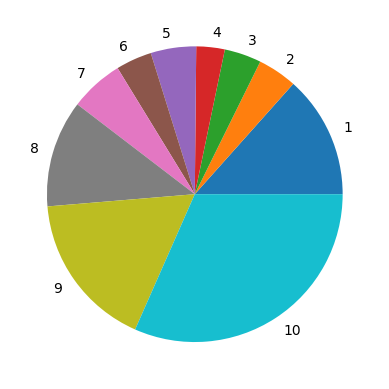

In [30]:
rating_dist = drugs_train['rating'].value_counts().to_dict()

rating_levels = list(range(1, 11))
rating_counts = [rating_dist[s] for s in rating_levels]

fig, ax = plt.subplots()
ax.pie(rating_counts, labels = list(map(str, rating_levels)))
plt.show()

Rating distribution is heavily imbalanced. TODO: perform balancing.

Current Rating-to-Sentiment Mapping:
- \[1..4\]: NEGATIVE
- \[5..8\]: NEUTRAL
- \[9..10\]: POSITIVE

Too many 9s and 10s, this setting will favour the POSITIVE label.

In [31]:
SENTIMENT_LABEL_MAP = {
    0: 'NEGATIVE',
    1: 'NEUTRAL',
    2: 'POSITIVE'
}

def rating_to_label(rating):
    rating = int(rating)
    if 1 <= rating <= 4:
        return 0
    elif 5 <= rating <= 8:
        return 1
    else:
        return 2

drugs_train['sentiment'] = drugs_train['rating'].map(rating_to_label)
drugs_test['sentiment'] = drugs_test['rating'].map(rating_to_label)

In [9]:
drugs_train

,uniqueID,drugName,condition,review,rating,date,usefulCount,sentiment
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27,2
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192,1
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17,1
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10,1
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37,2
...,...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125,2
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34,0
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35,0
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79,2


In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def normalize_text(text: str) -> str:
    text = html.unescape(text)
    text = unidecode(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)

    # text = re.sub(r"[^a-z0-9\s'\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

def remove_stopwords(tokens: list[str]) -> list[str]:
    return list(
        filter(
            lambda t : t not in stop_words and len(t) > 1,
            tokens
        )
    )

def lemmatize(tokens: list[str]) -> list[str]:
    return list(
        map(
            lambda t: lemmatizer.lemmatize(t),
            tokens
        )
    )

class TextPreprocessor:
    transformations: list[Callable]

    def __init__(self) -> None:
        self.transformations = []

    def add(self, tfomer: Callable):
        self.transformations.append(tfomer)
        return self

    def __call__(self, sample: str) -> Any:
        for tform in self.transformations:
            sample = tform(sample)
        return sample

In [11]:
preprocessor = TextPreprocessor() \
    .add(normalize_text) \
    .add(nltk.word_tokenize) \
    # .add(remove_stopwords) \
    # .add(lemmatize)

vectorizer_tfidf = TfidfVectorizer(
    lowercase     = False, # already handled
    tokenizer     = preprocessor,

    stop_words    = None, # again, already handled
    ngram_range   = (2, 2),
    token_pattern = None, # pyright: ignore[reportArgumentType]

    min_df       = 2,
    max_df       = 0.95,
    sublinear_tf = True
)

In [12]:
train_tfidf = vectorizer_tfidf.fit_transform(drugs_train['review'])
test_tfidf  = vectorizer_tfidf.transform(drugs_test['review'])

In [13]:
clf_svc = LinearSVC(class_weight = 'balanced')
clf_svc.fit(X = train_tfidf, y = drugs_train['sentiment'].to_list())

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [14]:
test_pred = clf_svc.predict(X = test_tfidf)
print(classification_report(drugs_test['sentiment'].to_list(), test_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89     13497
           1       0.80      0.76      0.78     14076
           2       0.90      0.91      0.90     26193

    accuracy                           0.87     53766
   macro avg       0.86      0.85      0.86     53766
weighted avg       0.86      0.87      0.86     53766



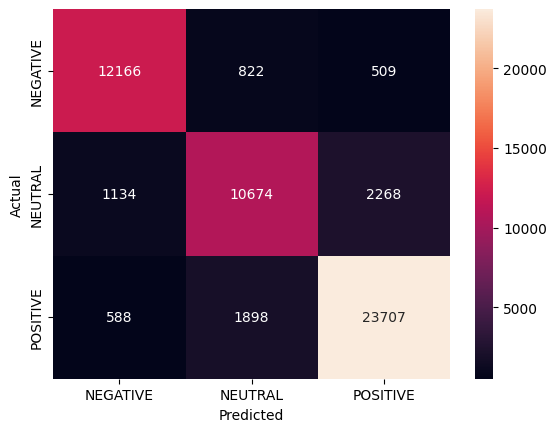

In [47]:
conf_mat = confusion_matrix(y_true = drugs_test['sentiment'].to_numpy(), y_pred = test_pred)
ticklabels = list(map(lambda lb : lb[1], sorted(SENTIMENT_LABEL_MAP.items(), key = lambda lb : lb[0])))
sns.heatmap(conf_mat, annot = True, fmt = 'd', xticklabels = ticklabels, yticklabels = ticklabels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
ipred = clf_svc.predict(X = vectorizer_tfidf.transform(['This medicine helped cure my throat problem.']))
SENTIMENT_LABEL_MAP[int(ipred[0])]

'POSITIVE'

In [22]:
ipred = clf_svc.predict(X = vectorizer_tfidf.transform(['This medicine did not help curing my throat problem.']))
SENTIMENT_LABEL_MAP[int(ipred[0])]

'NEGATIVE'